In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11


GREEN, AMBER, RUST, GREY = "#1E3A2B", "#D9A13B", "#C0552B", "#6B7280"

SEED = 42
np.random.seed(SEED)
print("Setup complete.")

Setup complete.


In [2]:

STEP_MIN      = 5                      # one sensor reading every 5 minutes
STEPS_PER_DAY = 24 * 60 // STEP_MIN    # = 288 readings per day

ALPHA      = 0.07   # thermal inertia: how fast shed air follows the target (~70 min time constant)
BETA       = 0.22   # how fast humidity responds
BIRD_HEAT  = 3.6    # °C added by the flock's body heat
FAN_COOL   = 3.0    # °C of cooling the fan can provide
AMBIENT_MEAN = 26.0 # °C mean outdoor temperature
AMBIENT_AMP  = 7.5  # °C day/night swing


def temperature_humidity_index(t_c, rh_pct):
    '''Livestock Temperature-Humidity Index. Higher = more heat stress.'''
    return 0.8 * t_c + (rh_pct / 100.0) * (t_c - 14.4) + 46.4


def simulate_shed(n_days=30, seed=SEED, controller=None):
    '''
    Generate synthetic poultry-shed sensor data.

    controller : None  -> a simple reactive thermostat with a jittered daily
                          threshold (used to create varied TRAINING data)
                 func  -> your own controller: f(temp_history, hum_history, fan_now) -> bool
    '''
    rng = np.random.default_rng(seed)
    n   = n_days * STEPS_PER_DAY

    day_offset    = rng.normal(0, 1.8, n_days + 1)          # hotter / cooler days
    day_threshold = rng.uniform(29.5, 32.0, n_days + 1)     # jitter so training data varies

    temp, rh, litter, aq = 26.0, 70.0, 38.0, 430.0
    fan, leak_left, gust, fan_on_for = False, 0, 0.0, 0
    rows, hist_t, hist_h = [], [], []

    for i in range(n):
        day  = i // STEPS_PER_DAY
        hour = (i % STEPS_PER_DAY) * STEP_MIN / 60.0

        # --- 1. outdoor temperature ---
        gust    = 0.85 * gust + rng.normal(0, 0.35)                      # smooth random weather
        ambient = (AMBIENT_MEAN
                   + AMBIENT_AMP * np.sin(2 * np.pi * (hour - 9) / 24.0) # peaks ~15:00
                   + day_offset[day] + gust
                   + 1.0 * np.sin(2 * np.pi * i / n))                    # slow seasonal drift

        # --- 2. water leak events (rare, last 1-3 hours) ---
        if leak_left == 0 and rng.random() < 0.0018:
            leak_left = int(rng.integers(12, 40))
        leaking = leak_left > 0
        if leaking:
            leak_left -= 1

        # --- 3. litter moisture ---
        litter += 0.012 * (37.0 - litter) + rng.normal(0, 0.12)          # pulled to baseline
        litter += 0.75 if leaking else (-0.03 - (0.05 if fan else 0.0))  # leak wets, fan dries
        litter  = float(np.clip(litter, 22, 75))

        # --- 4. shed temperature (lagged response = thermal inertia) ---
        target_temp = ambient + BIRD_HEAT - (FAN_COOL if fan else 0.0)
        temp += ALPHA * (target_temp - temp) + rng.normal(0, 0.05)

        # --- 5. humidity ---
        target_rh = 82 - 1.6 * (temp - 24) + 0.30 * (litter - 38) - (9 if fan else 0)
        rh += BETA * (target_rh - rh) + rng.normal(0, 0.3)
        rh  = float(np.clip(rh, 30, 95))

        # --- 6. air quality / ammonia ---
        target_aq = 380 + 11 * (litter - 35) + 7 * (temp - 28) - (75 if fan else 0)
        aq += 0.20 * (target_aq - aq) + rng.normal(0, 4)
        aq  = float(np.clip(aq, 350, 1200))

        # --- 7. what the sensors actually report (with measurement noise) ---
        t_meas = temp + rng.normal(0, 0.15)                    # DHT22 accuracy ~ ±0.2 °C
        h_meas = float(np.clip(rh + rng.normal(0, 0.8), 30, 99))

        rows.append((i, day, round(hour, 2), t_meas, h_meas,
                     litter, aq, int(leaking), int(fan)))
        hist_t.append(t_meas); hist_h.append(h_meas)

        # --- 8. decide the fan state for the NEXT step ---
        if controller is None:
            want_fan = t_meas >= day_threshold[day]
        else:
            want_fan = controller(hist_t, hist_h, fan)
        if fan and fan_on_for < 3:      # minimum 15-min run time, stops rapid on/off chatter
            want_fan = True
        fan_on_for = fan_on_for + 1 if want_fan else 0
        fan = want_fan

    df = pd.DataFrame(rows, columns=["step", "day", "hour", "temp_c", "humidity_pct",
                                     "litter_moist_pct", "air_quality_ppm",
                                     "water_leak", "fan_on"])
    df["thi"] = temperature_humidity_index(df.temp_c, df.humidity_pct)
    return df


print("Virtual shed ready.")

Virtual shed ready.


In [3]:
data = simulate_shed(n_days=30, seed=SEED)

print(f"Rows: {len(data):,}   ({len(data)*STEP_MIN/60/24:.0f} days at one reading every {STEP_MIN} min)")
print(f"Water-leak readings : {data.water_leak.sum():,}  ({100*data.water_leak.mean():.1f}% of the time)")
print(f"Fan running          : {100*data.fan_on.mean():.1f}% of the time")
data.head(8)

Rows: 8,640   (30 days at one reading every 5 min)
Water-leak readings : 438  (5.1% of the time)
Fan running          : 38.1% of the time


,step,day,hour,temp_c,humidity_pct,litter_moist_pct,air_quality_ppm,water_leak,fan_on,thi
0,0,0,0.00,25.854935,71.810654,37.977530,426.794097,0,0,75.309812
1,1,0,0.08,25.775615,73.985533,37.782718,422.401852,0,0,75.436802
2,2,0,0.17,25.582565,74.561277,37.818396,414.166081,0,0,75.203915
3,3,0,0.25,25.610366,75.951388,37.722247,411.622714,0,0,75.402721
4,4,0,0.33,25.369404,75.727175,37.481100,403.000816,0,0,75.002343
5,5,0,0.42,25.080361,76.651025,37.402575,398.976578,0,0,74.650895
6,6,0,0.50,25.149699,76.998343,37.419875,390.715187,0,0,74.796849
7,7,0,0.58,25.072466,78.815605,37.577050,390.814015,0,0,74.869542


In [4]:
data[["temp_c", "humidity_pct", "litter_moist_pct", "air_quality_ppm", "thi"]].describe().round(2)

,temp_c,humidity_pct,litter_moist_pct,air_quality_ppm,thi
count,8640.00,8640.00,8640.00,8640.00,8640.00
mean,28.48,70.87,36.31,382.20,78.74
std,4.20,10.78,5.34,52.75,4.96
min,19.33,50.09,28.95,350.00,66.20
25%,24.85,60.12,33.21,350.00,74.63
50%,29.22,72.61,34.12,356.10,80.25
75%,31.73,80.41,37.43,389.10,82.53
max,36.99,92.19,61.20,659.51,87.97


In [5]:
data.to_csv("poultry_shed_synthetic.csv", index=False)
print("Saved -> poultry_shed_synthetic.csv")
print("(In Colab: open the folder icon on the left to download it.)")

Saved -> poultry_shed_synthetic.csv
(In Colab: open the folder icon on the left to download it.)


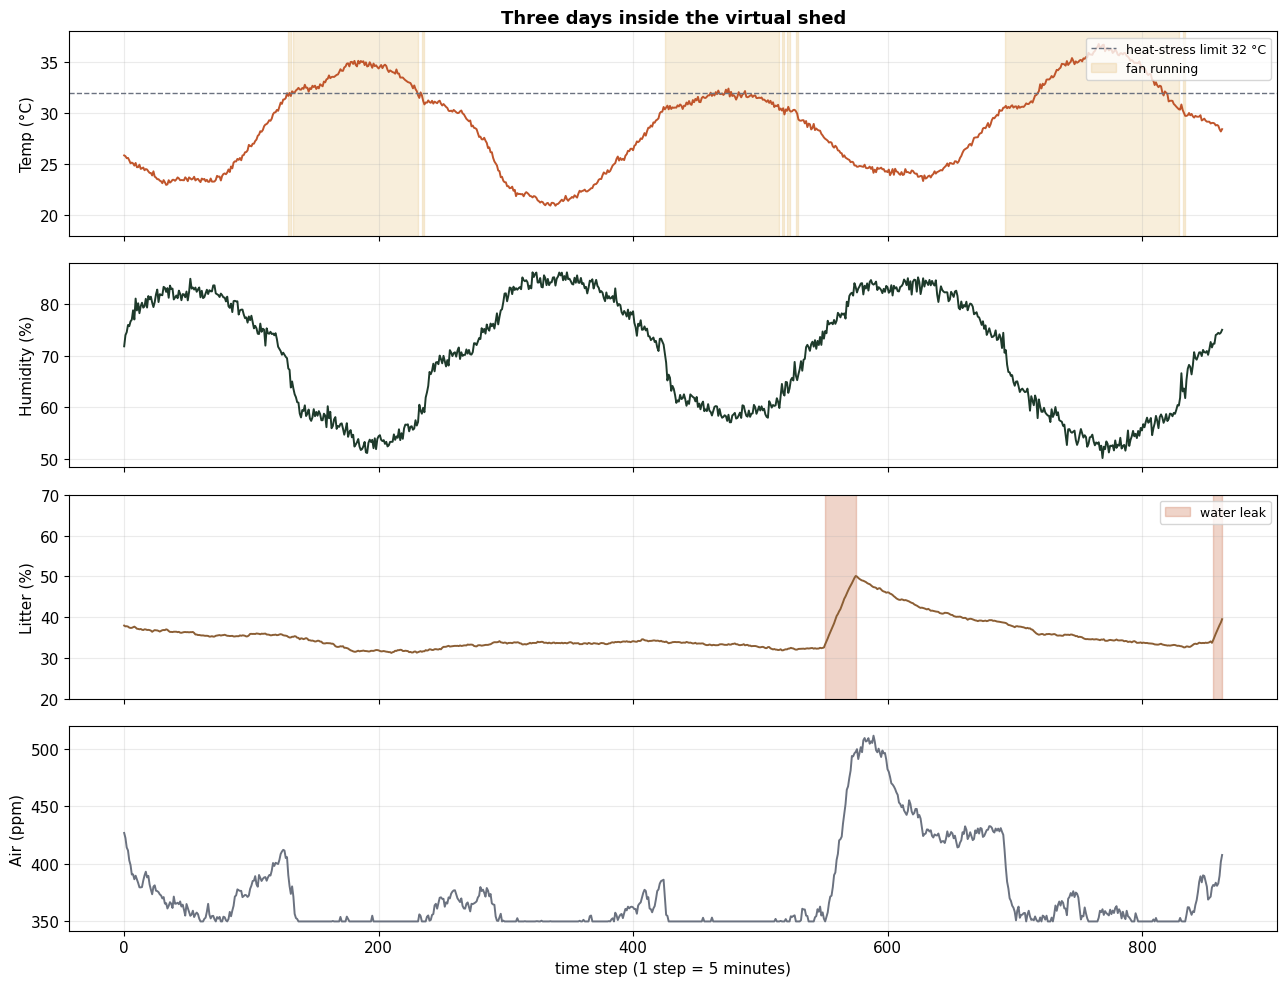

In [6]:
w = data[data.day < 3]
fig, ax = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

ax[0].plot(w.step, w.temp_c, color=RUST, lw=1.4)
ax[0].axhline(32, color=GREY, ls="--", lw=1, label="heat-stress limit 32 °C")
ax[0].fill_between(w.step, 0, 45, where=w.fan_on == 1, color=AMBER, alpha=0.18, label="fan running")
ax[0].set_ylim(18, 38); ax[0].set_ylabel("Temp (°C)"); ax[0].legend(loc="upper right", fontsize=9)
ax[0].set_title("Three days inside the virtual shed", fontsize=13, weight="bold")

ax[1].plot(w.step, w.humidity_pct, color=GREEN, lw=1.4); ax[1].set_ylabel("Humidity (%)")

ax[2].plot(w.step, w.litter_moist_pct, color="#8B5E34", lw=1.4)
ax[2].fill_between(w.step, 0, 80, where=w.water_leak == 1, color=RUST, alpha=0.25, label="water leak")
ax[2].set_ylim(20, 70); ax[2].set_ylabel("Litter (%)"); ax[2].legend(loc="upper right", fontsize=9)

ax[3].plot(w.step, w.air_quality_ppm, color=GREY, lw=1.4)
ax[3].set_ylabel("Air (ppm)"); ax[3].set_xlabel("time step (1 step = 5 minutes)")

plt.tight_layout(); plt.savefig("fig1_three_days.png", dpi=150, bbox_inches="tight"); plt.show()

In [7]:
HORIZON = 6   # 6 steps x 5 min = 30 minutes ahead.  Try 9 (45 min) or 12 (60 min).

def build_features(df, horizon=HORIZON):
    d = df.copy()
    d["t10"] = d.temp_c.shift(2)            # 10 minutes ago
    d["t20"] = d.temp_c.shift(4)            # 20 minutes ago
    d["h20"] = d.humidity_pct.shift(4)
    d["future_temp"] = d.temp_c.shift(-horizon)        # <- what we predict
    d["future_hum"]  = d.humidity_pct.shift(-horizon)
    return d.dropna().reset_index(drop=True)

FEATURES = ["temp_c", "t10", "t20", "humidity_pct", "h20"]

ds  = build_features(data)
cut = int(len(ds) * 0.70)
train, test = ds[:cut], ds[cut:]

print(f"Predicting {HORIZON * STEP_MIN} minutes ahead")
print(f"Train : {len(train):,} rows  (days {train.day.min()}-{train.day.max()})")
print(f"Test  : {len(test):,} rows  (days {test.day.min()}-{test.day.max()})")

Predicting 30 minutes ahead
Train : 6,041 rows  (days 0-20)
Test  : 2,589 rows  (days 20-29)


In [8]:
model_temp = LinearRegression().fit(train[FEATURES], train.future_temp)
model_hum  = LinearRegression().fit(train[FEATURES], train.future_hum)

pred_temp = model_temp.predict(test[FEATURES])
pred_hum  = model_hum.predict(test[FEATURES])

def report(name, y_true, y_pred, y_naive, unit):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    base = mean_absolute_error(y_true, y_naive)
    print(f"{name}")
    print(f"   MAE               : {mae:.3f} {unit}")
    print(f"   RMSE              : {rmse:.3f} {unit}")
    print(f"   R²                : {r2:.4f}")
    print(f"   Persistence MAE   : {base:.3f} {unit}   <- the 'do nothing' baseline")
    print(f"   Improvement       : {100*(1-mae/base):.1f}% better than baseline\n")
    return mae, rmse, r2, base

print("=" * 58)
print(f"RESULTS  —  {HORIZON*STEP_MIN}-minute ahead forecast (unseen test days)")
print("=" * 58)
mt = report("TEMPERATURE", test.future_temp, pred_temp, test.temp_c, "°C")
mh = report("HUMIDITY",    test.future_hum,  pred_hum,  test.humidity_pct, "%")

RESULTS  —  30-minute ahead forecast (unseen test days)
TEMPERATURE
   MAE               : 0.381 °C
   RMSE              : 0.473 °C
   R²                : 0.9868
   Persistence MAE   : 0.521 °C   <- the 'do nothing' baseline
   Improvement       : 27.0% better than baseline

HUMIDITY
   MAE               : 1.344 %
   RMSE              : 1.762 %
   R²                : 0.9731
   Persistence MAE   : 1.619 %   <- the 'do nothing' baseline
   Improvement       : 17.0% better than baseline



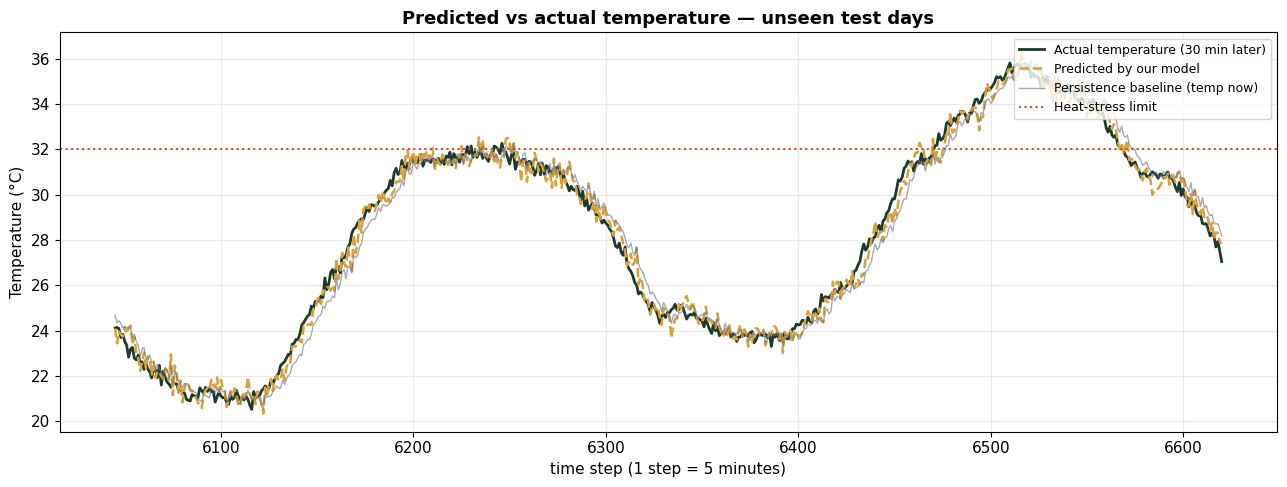

In [9]:
show = test.iloc[:576]   # two days of test data
plt.figure(figsize=(13, 5))
plt.plot(show.step, show.future_temp, color=GREEN, lw=2, label="Actual temperature (30 min later)")
plt.plot(show.step, model_temp.predict(show[FEATURES]), color=AMBER, lw=1.8, ls="--",
         label="Predicted by our model")
plt.plot(show.step, show.temp_c, color=GREY, lw=1, alpha=0.6, label="Persistence baseline (temp now)")
plt.axhline(32, color=RUST, ls=":", lw=1.5, label="Heat-stress limit")
plt.title("Predicted vs actual temperature — unseen test days", fontsize=13, weight="bold")
plt.xlabel("time step (1 step = 5 minutes)"); plt.ylabel("Temperature (°C)")
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.savefig("fig2_prediction.png", dpi=150, bbox_inches="tight"); plt.show()

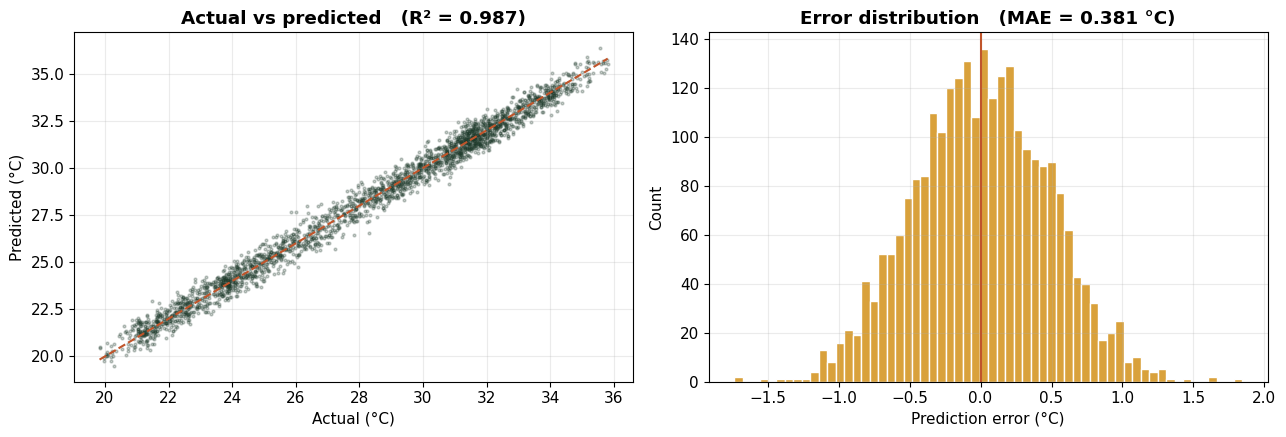

90% of predictions are within 0.78 °C of the true value.


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].scatter(test.future_temp, pred_temp, s=4, alpha=0.25, color=GREEN)
lo, hi = test.future_temp.min(), test.future_temp.max()
ax[0].plot([lo, hi], [lo, hi], color=RUST, lw=1.5, ls="--")
ax[0].set_xlabel("Actual (°C)"); ax[0].set_ylabel("Predicted (°C)")
ax[0].set_title(f"Actual vs predicted   (R² = {mt[2]:.3f})", weight="bold")

err = pred_temp - test.future_temp
ax[1].hist(err, bins=60, color=AMBER, edgecolor="white")
ax[1].axvline(0, color=RUST, lw=1.5)
ax[1].set_xlabel("Prediction error (°C)"); ax[1].set_ylabel("Count")
ax[1].set_title(f"Error distribution   (MAE = {mt[0]:.3f} °C)", weight="bold")

plt.tight_layout(); plt.savefig("fig3_accuracy.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"90% of predictions are within {np.percentile(np.abs(err), 90):.2f} °C of the true value.")

In [11]:
THI_WARNING, THI_CRITICAL = 78.0, 82.0
TEMP_LIMIT = 32.0

def risk_level(t, rh):
    thi = temperature_humidity_index(t, rh)
    if thi >= THI_CRITICAL or t >= TEMP_LIMIT: return "CRITICAL"
    if thi >= THI_WARNING:                     return "WARNING"
    return "SAFE"

for t, rh in [(26, 60), (29, 70), (31, 80), (34, 85)]:
    print(f"{t} °C / {rh}% RH  ->  THI {temperature_humidity_index(t, rh):5.1f}  ->  {risk_level(t, rh)}")

26 °C / 60% RH  ->  THI  74.2  ->  SAFE
29 °C / 70% RH  ->  THI  79.8  ->  WARNING
31 °C / 80% RH  ->  THI  84.5  ->  CRITICAL
34 °C / 85% RH  ->  THI  90.3  ->  CRITICAL


In [12]:
ev = simulate_shed(n_days=10, seed=2024)          # fresh, unseen weather
T, Hh = ev.temp_c.values, ev.humidity_pct.values
W, B  = model_temp.coef_, model_temp.intercept_

forecast = np.full(len(T), np.nan)
for i in range(4, len(T) - HORIZON):
    forecast[i] = (W[0]*T[i] + W[1]*T[i-2] + W[2]*T[i-4] + W[3]*Hh[i] + W[4]*Hh[i-4] + B)

warned   = forecast >= TEMP_LIMIT                 # model says: trouble coming
happened = T >= TEMP_LIMIT                        # it actually got too hot

events = np.where(happened[1:] & ~happened[:-1])[0] + 1        # start of each heat event
LOOKBACK = 24                                                  # search up to 2 h before

leads = []
for e in events:
    win = np.where(warned[max(0, e - LOOKBACK):e])[0]
    leads.append((e - (max(0, e - LOOKBACK) + win[0])) * STEP_MIN if len(win) else 0)
leads = np.array(leads)

onsets = np.where(warned[1:] & ~warned[:-1])[0] + 1            # each new warning
true_alarms = sum(1 for o in onsets if happened[o:o + 10].any())

print("=" * 58)
print("EARLY-WARNING PERFORMANCE  (10 unseen days)")
print("=" * 58)
print(f"Heat-stress events            : {len(events)}")
print(f"Events warned in advance      : {(leads > 0).sum()} / {len(events)}"
      f"   ({100*(leads>0).mean():.0f}% recall)")
print(f"Average warning time          : {leads.mean():.0f} minutes")
print(f"Median warning time           : {np.median(leads):.0f} minutes")
print(f"Warnings raised               : {len(onsets)}")
print(f"Precision (real / all alarms) : {100*true_alarms/len(onsets):.0f}%")
print("=" * 58)

EARLY-WARNING PERFORMANCE  (10 unseen days)
Heat-stress events            : 24
Events warned in advance      : 24 / 24   (100% recall)
Average warning time          : 70 minutes
Median warning time           : 60 minutes
Warnings raised               : 37
Precision (real / all alarms) : 95%


In [13]:
FAN_ON_AT, FAN_OFF_AT = 32.0, 30.5

def reactive_controller(temp_hist, hum_hist, fan_now):
    '''System A - the original rule-based logic.'''
    t = temp_hist[-1]
    if t >= FAN_ON_AT:  return True
    if t <= FAN_OFF_AT: return False
    return fan_now

def predict_ahead(temp_hist, hum_hist):
    '''The exact arithmetic the ESP32 will run.'''
    return (W[0]*temp_hist[-1] + W[1]*temp_hist[-3] + W[2]*temp_hist[-5]
            + W[3]*hum_hist[-1] + W[4]*hum_hist[-5] + B)

def predictive_controller(temp_hist, hum_hist, fan_now):
    '''System B - rule-based logic PLUS the 30-minute forecast.'''
    t = temp_hist[-1]
    if len(temp_hist) < 5:                       # not enough history yet -> fall back
        return reactive_controller(temp_hist, hum_hist, fan_now)
    forecast = predict_ahead(temp_hist, hum_hist)
    if t >= FAN_ON_AT or forecast >= FAN_ON_AT:  return True
    if t <= FAN_OFF_AT and forecast < FAN_OFF_AT: return False
    return fan_now

DEMO_DAYS, DEMO_SEED = 7, 777
run_a = simulate_shed(DEMO_DAYS, DEMO_SEED, controller=reactive_controller)
run_b = simulate_shed(DEMO_DAYS, DEMO_SEED, controller=predictive_controller)
print(f"Simulated {DEMO_DAYS} days under both systems.")

Simulated 7 days under both systems.


In [14]:
def score(df, label):
    return {
        "System": label,
        "Minutes above 32 °C":  int(STEP_MIN * (df.temp_c > TEMP_LIMIT).sum()),
        "Minutes THI CRITICAL": int(STEP_MIN * (df.thi > THI_CRITICAL).sum()),
        "Peak temperature (°C)": round(df.temp_c.max(), 2),
        "Mean THI":             round(df.thi.mean(), 2),
        "Fan runtime (%)":      round(100 * df.fan_on.mean(), 1),
    }

comparison = pd.DataFrame([score(run_a, "A — Reactive (rules only)"),
                           score(run_b, "B — Predictive (with ML)")])

heat_cut = 100 * (1 - (run_b.temp_c > TEMP_LIMIT).sum() / max((run_a.temp_c > TEMP_LIMIT).sum(), 1))
fan_cost = 100 * (run_b.fan_on.mean() / max(run_a.fan_on.mean(), 1e-9) - 1)

display(comparison)
print(f"\n>>> Heat-stress exposure reduced by {heat_cut:.1f}%")
print(f">>> Extra fan runtime cost         : {fan_cost:+.1f}%")

,System,Minutes above 32 °C,Minutes THI CRITICAL,Peak temperature (°C),Mean THI,Fan runtime (%)
0,A — Reactive (rules only),1890,3540,35.27,78.39,30.1
1,B — Predictive (with ML),1695,3310,35.27,78.32,31.4



>>> Heat-stress exposure reduced by 10.3%
>>> Extra fan runtime cost         : +4.4%


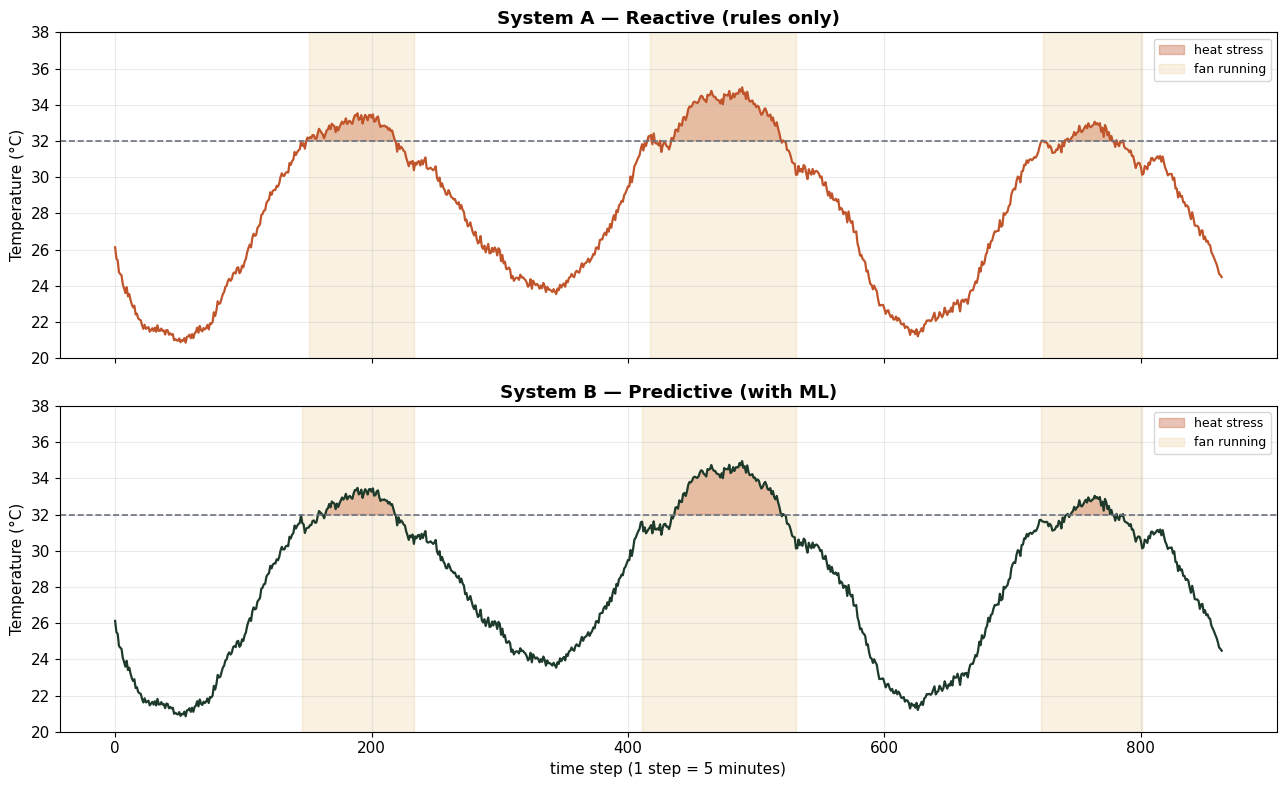

In [15]:
w = run_a[run_a.day < 3]; v = run_b[run_b.day < 3]
fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True, sharey=True)

for a, d, ttl, col in ((ax[0], w, "System A — Reactive (rules only)", RUST),
                       (ax[1], v, "System B — Predictive (with ML)", GREEN)):
    a.plot(d.step, d.temp_c, color=col, lw=1.6)
    a.axhline(TEMP_LIMIT, color=GREY, ls="--", lw=1.2)
    a.fill_between(d.step, TEMP_LIMIT, d.temp_c, where=d.temp_c > TEMP_LIMIT,
                   color=RUST, alpha=0.35, label="heat stress")
    a.fill_between(d.step, 18, 40, where=d.fan_on == 1, color=AMBER, alpha=0.15, label="fan running")
    a.set_title(ttl, weight="bold"); a.set_ylabel("Temperature (°C)")
    a.legend(loc="upper right", fontsize=9); a.set_ylim(20, 38)

ax[1].set_xlabel("time step (1 step = 5 minutes)")
plt.tight_layout(); plt.savefig("fig4_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

In [16]:
BOX_W = 50   # fixed width so every border lines up

def _row(text):
    return "\u2502 " + text.ljust(BOX_W - 3) + "\u2502"

def _rule(left, mid, right):
    return left + mid * (BOX_W - 2) + right

def build_alert(t_now, rh_now, t_pred, rh_pred, minutes):
    thi_now  = temperature_humidity_index(t_now, rh_now)
    thi_pred = temperature_humidity_index(t_pred, rh_pred)
    level = risk_level(t_pred, rh_pred)
    mark  = {"SAFE": "[ OK ]", "WARNING": "[ !  ]", "CRITICAL": "[ !! ]"}[level]
    trend = ("rising"  if t_pred > t_now + 0.3 else
             "falling" if t_pred < t_now - 0.3 else "steady")

    body = [f"{mark}  POULTRYGUARD  -  {level}",
            None,
            f"Now       : {t_now:5.1f} °C | {rh_now:4.1f} % | THI {thi_now:5.1f}",
            f"In {minutes:2d} min : {t_pred:5.1f} °C | {rh_pred:4.1f} % | THI {thi_pred:5.1f}",
            f"Trend     : {trend}",
            None]

    if level == "CRITICAL":
        body += [f"Heat stress predicted in ~{minutes} minutes.",
                 "ACTION: fan started automatically.",
                 "Check drinkers and open the side curtains."]
    elif level == "WARNING":
        body += ["Conditions drifting upward.",
                 "ACTION: monitoring closely, fan on standby."]
    else:
        body += ["All conditions normal.",
                 "No action needed."]

    out = [_rule("\u250c", "\u2500", "\u2510")]
    for b in body:
        out.append(_rule("\u251c", "\u2500", "\u2524") if b is None else _row(b))
    out.append(_rule("\u2514", "\u2500", "\u2518"))
    return "\n".join(out)


def feature_row(T_arr, H_arr, k):
    '''Build one properly-named feature row (keeps scikit-learn quiet).'''
    return pd.DataFrame([[T_arr[k], T_arr[k-2], T_arr[k-4], H_arr[k], H_arr[k-4]]],
                        columns=FEATURES)


# Pick a real moment from the test data where the model saw trouble coming
i = int(np.argmax(forecast >= TEMP_LIMIT))
print(build_alert(T[i], Hh[i], forecast[i],
                  model_hum.predict(feature_row(T, Hh, i))[0],
                  HORIZON * STEP_MIN))
print("\n\n--- a calm moment, for contrast ---\n")
j = int(np.argmin(np.nan_to_num(forecast, nan=99)))
print(build_alert(T[j], Hh[j], forecast[j],
                  model_hum.predict(feature_row(T, Hh, j))[0],
                  HORIZON * STEP_MIN))

┌────────────────────────────────────────────────┐
│ [ !! ]  POULTRYGUARD  -  CRITICAL              │
├────────────────────────────────────────────────┤
│ Now       :  31.8 °C | 61.0 % | THI  82.4      │
│ In 30 min :  32.4 °C | 59.8 % | THI  83.1      │
│ Trend     : rising                             │
├────────────────────────────────────────────────┤
│ Heat stress predicted in ~30 minutes.          │
│ ACTION: fan started automatically.             │
│ Check drinkers and open the side curtains.     │
└────────────────────────────────────────────────┘


--- a calm moment, for contrast ---

┌────────────────────────────────────────────────┐
│ [ OK ]  POULTRYGUARD  -  SAFE                  │
├────────────────────────────────────────────────┤
│ Now       :  19.4 °C | 85.7 % | THI  66.1      │
│ In 30 min :  19.0 °C | 88.3 % | THI  65.7      │
│ Trend     : falling                            │
├────────────────────────────────────────────────┤
│ All conditions normal.                   

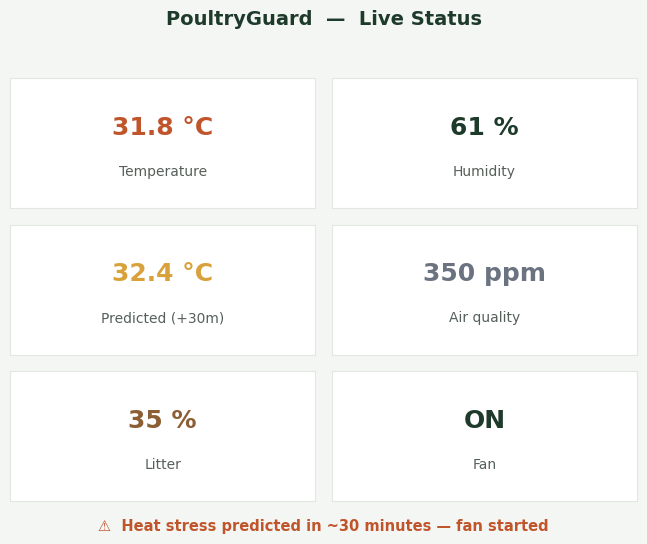

In [17]:

k = i
tiles = [("Temperature", f"{T[k]:.1f} °C", RUST),
         ("Humidity",    f"{Hh[k]:.0f} %",  GREEN),
         (f"Predicted (+{HORIZON*STEP_MIN}m)", f"{forecast[k]:.1f} °C", AMBER),
         ("Air quality", f"{ev.air_quality_ppm.values[k]:.0f} ppm", GREY),
         ("Litter",      f"{ev.litter_moist_pct.values[k]:.0f} %",  "#8B5E34"),
         ("Fan",         "ON", GREEN)]

fig, axes = plt.subplots(3, 2, figsize=(6.6, 5.4))
fig.patch.set_facecolor("#F4F6F3")
for a, (lab, val, col) in zip(axes.ravel(), tiles):
    a.set_facecolor("white"); a.set_xticks([]); a.set_yticks([])
    for s in a.spines.values(): s.set_edgecolor("#E3E7E1")
    a.text(0.5, 0.62, val, ha="center", va="center", fontsize=18, weight="bold", color=col)
    a.text(0.5, 0.28, lab, ha="center", va="center", fontsize=10, color="#55605A")

fig.suptitle("PoultryGuard  —  Live Status", fontsize=14, weight="bold", color=GREEN, y=0.97)
fig.text(0.5, 0.005, f"⚠  Heat stress predicted in ~{HORIZON*STEP_MIN} minutes — fan started",
         ha="center", fontsize=10.5, weight="bold", color=RUST)
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.savefig("fig5_dashboard.png", dpi=150, bbox_inches="tight"); plt.show()

In [18]:
Wt, Bt = model_temp.coef_, model_temp.intercept_
Wh, Bh = model_hum.coef_,  model_hum.intercept_

print(f'''// =====================================================================
//  PoultryGuard - prediction model
//  Trained in Google Colab on {len(train):,} synthetic readings.
//  Predicts {HORIZON*STEP_MIN} minutes ahead.  Test MAE: {mt[0]:.3f} C / {mh[0]:.3f} %RH
// =====================================================================

// Ring buffer: one reading every {STEP_MIN} minutes, newest last.
float tempHist[5], humHist[5];

float predictTemp(float t0, float t10, float t20, float h0, float h20) {{
  return {Wt[0]:+.6f}f * t0
       + {Wt[1]:+.6f}f * t10
       + {Wt[2]:+.6f}f * t20
       + {Wt[3]:+.6f}f * h0
       + {Wt[4]:+.6f}f * h20
       + {Bt:+.6f}f;
}}

float predictHumidity(float t0, float t10, float t20, float h0, float h20) {{
  return {Wh[0]:+.6f}f * t0
       + {Wh[1]:+.6f}f * t10
       + {Wh[2]:+.6f}f * t20
       + {Wh[3]:+.6f}f * h0
       + {Wh[4]:+.6f}f * h20
       + {Bh:+.6f}f;
}}

float computeTHI(float t, float rh) {{
  return 0.8f * t + (rh / 100.0f) * (t - 14.4f) + 46.4f;
}}

// ---- call this once every {STEP_MIN} minutes ----
void checkShed() {{
  float t0  = tempHist[4], t10 = tempHist[2], t20 = tempHist[0];
  float h0  = humHist[4],  h20 = humHist[0];

  float futureT   = predictTemp(t0, t10, t20, h0, h20);
  float futureRH  = predictHumidity(t0, t10, t20, h0, h20);
  float futureTHI = computeTHI(futureT, futureRH);

  if (t0 >= {FAN_ON_AT}f || futureT >= {FAN_ON_AT}f) {{
    digitalWrite(FAN_PIN, HIGH);
    sendAlert("Heat stress predicted in ~{HORIZON*STEP_MIN} min. Fan started.");
  }} else if (t0 <= {FAN_OFF_AT}f && futureT < {FAN_OFF_AT}f) {{
    digitalWrite(FAN_PIN, LOW);
  }}

  if (futureTHI >= {THI_CRITICAL}f) sendAlert("CRITICAL heat-stress risk predicted.");
  else if (futureTHI >= {THI_WARNING}f) sendAlert("Conditions drifting upward.");
}}''')

// =====================================================================
//  PoultryGuard - prediction model
//  Trained in Google Colab on 6,041 synthetic readings.
//  Predicts 30 minutes ahead.  Test MAE: 0.381 C / 1.344 %RH
// =====================================================================

// Ring buffer: one reading every 5 minutes, newest last.
float tempHist[5], humHist[5];

float predictTemp(float t0, float t10, float t20, float h0, float h20) {
  return +1.691934f * t0
       + +0.205406f * t10
       + -0.913060f * t20
       + -0.058177f * h0
       + +0.059372f * h20
       + +0.365720f;
}

float predictHumidity(float t0, float t10, float t20, float h0, float h20) {
  return -2.336840f * t0
       + +0.003429f * t10
       + +1.871820f * t20
       + +0.855076f * h0
       + -0.042655f * h20
       + +26.428122f;
}

float computeTHI(float t, float rh) {
  return 0.8f * t + (rh / 100.0f) * (t - 14.4f) + 46.4f;
}

// ---- call this once every 5 minutes ----
void checkS

In [19]:
print("=" * 60)
print("POULTRYGUARD — ML LAYER: RESULTS SUMMARY")
print("=" * 60)
print(f"Dataset            : {len(data):,} synthetic readings over 30 days")
print(f"Model              : Linear Regression, 5 inputs, 6 stored numbers")
print(f"Forecast horizon   : {HORIZON*STEP_MIN} minutes ahead")
print()
print(f"Temperature MAE    : {mt[0]:.2f} °C     (R² = {mt[2]:.3f})")
print(f"Humidity MAE       : {mh[0]:.2f} %RH    (R² = {mh[2]:.3f})")
print(f"Beats no-model baseline by : {100*(1-mt[0]/mt[3]):.0f}%")
print()
print(f"Heat events detected early  : {(leads>0).sum()}/{len(events)}  ({100*(leads>0).mean():.0f}%)")
print(f"Average early warning       : {leads.mean():.0f} minutes")
print(f"Alarm precision             : {100*true_alarms/len(onsets):.0f}%")
print()
print(f"Heat-stress exposure cut by : {heat_cut:.0f}%   (predictive vs reactive)")
print(f"Extra fan runtime           : {fan_cost:+.0f}%")
print()
print(f"ESP32 cost                  : 6 floats, ~{6*4} bytes, no ML library")
print("=" * 60)
print("\nFigures saved: fig1_three_days.png, fig2_prediction.png,")
print("               fig3_accuracy.png, fig4_comparison.png, fig5_dashboard.png")
print("Dataset saved: poultry_shed_synthetic.csv")

POULTRYGUARD — ML LAYER: RESULTS SUMMARY
Dataset            : 8,640 synthetic readings over 30 days
Model              : Linear Regression, 5 inputs, 6 stored numbers
Forecast horizon   : 30 minutes ahead

Temperature MAE    : 0.38 °C     (R² = 0.987)
Humidity MAE       : 1.34 %RH    (R² = 0.973)
Beats no-model baseline by : 27%

Heat events detected early  : 24/24  (100%)
Average early warning       : 70 minutes
Alarm precision             : 95%

Heat-stress exposure cut by : 10%   (predictive vs reactive)
Extra fan runtime           : +4%

ESP32 cost                  : 6 floats, ~24 bytes, no ML library

Figures saved: fig1_three_days.png, fig2_prediction.png,
               fig3_accuracy.png, fig4_comparison.png, fig5_dashboard.png
Dataset saved: poultry_shed_synthetic.csv
